# 📊 Notebook 01: MedPix Dataset Exploration & EDA

**Objective:** Thoroughly understand the MedPix multimodal dataset before any preprocessing.

**Sections:**
1. Load JSON files & inspect schema
2. Build the merged DataFrame (image ↔ case ↔ label)
3. Class distribution (raw + grouped)
4. Image grid visualization
5. Text statistics (caption length, vocabulary)
6. Class imbalance analysis + resampling strategy
7. Save dataset summary

In [1]:
import sys, os
sys.path.insert(0, '..')  # Make src/ and config.py importable from notebooks/

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import config

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print(f'MedPix Image Dir: {config.MEDPIX_IMAGE_DIR}')
print(f'Descriptions JSON: {config.MEDPIX_DESCRIPTIONS}')
print(f'Case Topic JSON:   {config.MEDPIX_CASE_TOPIC}')
print(f'Images dir exists: {config.MEDPIX_IMAGE_DIR.exists()}')

MedPix Image Dir: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Dataset\MedPix\images\images
Descriptions JSON: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Dataset\MedPix\Descriptions.json
Case Topic JSON:   Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Dataset\MedPix\Case_topic.json
Images dir exists: True


## 1️⃣ Load & Inspect Raw JSON Files

In [2]:
# Load Descriptions.json — one record per IMAGE (2050 total)
with open(config.MEDPIX_DESCRIPTIONS, 'r', encoding='utf-8') as f:
    descriptions = json.load(f)

# Load Case_topic.json — one record per CASE (671 total)
with open(config.MEDPIX_CASE_TOPIC, 'r', encoding='utf-8') as f:
    cases = json.load(f)

print(f'Total image records (Descriptions.json): {len(descriptions)}')
print(f'Total case records (Case_topic.json):    {len(cases)}')

# Inspect schemas
print('\n--- Sample Descriptions.json record ---')
print(json.dumps(descriptions[0], indent=2))

print('\n--- Sample Case_topic.json record ---')
print(json.dumps(cases[0], indent=2))

Total image records (Descriptions.json): 2050
Total case records (Case_topic.json):    671

--- Sample Descriptions.json record ---
{
  "Type": "CT",
  "U_id": "MPX1009",
  "image": "MPX1009_synpic46283",
  "Description": {
    "ACR Codes": "8.-1",
    "Age": "73",
    "Caption": "The prostate is enlarged with several calcifications  noted within.  No dominant prostate mass is evident.",
    "Figure Part": null,
    "Modality": "CT - noncontrast",
    "Plane": "Coronal",
    "Sex": "male"
  },
  "Location": "Genitourinary",
  "Location Category": "Reproductive and Urinary System"
}

--- Sample Case_topic.json record ---
{
  "U_id": "MPX1009",
  "TAC": [
    "MPX1009_synpic46283",
    "MPX1009_synpic46295"
  ],
  "MRI": [],
  "Case": {
    "Title": "Bladder Diverticulum",
    "History": "73-year-old male with hematuria and numerous white blood cells found on UA",
    "Exam": "N/A",
    "Findings": "Bladder with thickened wall and diverticulum on the right.  Diverticulum is mostly likely

In [3]:
# ── Build master DataFrame ──────────────────────────────────────────────────
# 1. Build case lookup: U_id → case dict
case_lookup = {c['U_id']: c for c in cases}

rows = []
missing_cases = 0
missing_images = 0

for rec in descriptions:
    uid   = rec.get('U_id', '')
    image_id = rec.get('image', '')
    img_path = config.MEDPIX_IMAGE_DIR / f'{image_id}.png'
    
    # Skip if image file does not exist
    if not img_path.exists():
        missing_images += 1
        continue
    
    # Get the case info
    case_info = case_lookup.get(uid)
    if not case_info:
        missing_cases += 1
        continue
    
    desc = rec.get('Description', {})
    case = case_info.get('Case', {})
    topic = case_info.get('Topic', {})
    
    # Combine caption + history for rich text representation
    caption = str(desc.get('Caption', '') or '').strip()
    history = str(case.get('History', '') or '').strip()
    findings = str(case.get('Findings', '') or '').strip()
    combined_text = ' '.join(filter(None, [history, findings, caption]))

    rows.append({
        'image_id':          image_id,
        'image_path':        str(img_path),
        'U_id':              uid,
        'modality':          rec.get('Type', 'Unknown'),
        'location':          rec.get('Location', 'Unknown'),
        'location_category': rec.get('Location Category', 'Unknown'),
        'plane':             desc.get('Plane', 'Unknown'),
        'age':               desc.get('Age', None),
        'sex':               desc.get('Sex', 'Unknown'),
        'caption':           caption,
        'history':           history,
        'findings':          findings,
        'text':              combined_text,
        'diagnosis':         case.get('Case Diagnosis', 'Unknown'),
        'raw_category':      topic.get('Category', 'Unknown'),
        'acr_code':          topic.get('ACR Code', ''),
        'disease_discussion': topic.get('Disease Discussion', ''),
    })

df = pd.DataFrame(rows)
print(f'Total usable records: {len(df)}')
print(f'Skipped (missing image file): {missing_images}')
print(f'Skipped (missing case data):  {missing_cases}')
df.head(3)

Total usable records: 2050
Skipped (missing image file): 0
Skipped (missing case data):  0


,image_id,image_path,U_id,modality,location,location_category,plane,age,sex,caption,history,findings,text,diagnosis,raw_category,acr_code,disease_discussion
0,MPX1009_synpic46283,Z:\study files\SRM_study\SEM-2\AML-509_Agentic...,MPX1009,CT,Genitourinary,Reproductive and Urinary System,Coronal,73,male,The prostate is enlarged with several calcific...,73-year-old male with hematuria and numerous w...,Bladder with thickened wall and diverticulum o...,73-year-old male with hematuria and numerous w...,Bladder Diverticulum,Diverticulum,8.9,Bladder diverticula most often occur as a resu...
1,MPX1009_synpic46295,Z:\study files\SRM_study\SEM-2\AML-509_Agentic...,MPX1009,CT,Genitourinary,Reproductive and Urinary System,Axial,73,male,Bladder is prominent with mildly thickened wal...,73-year-old male with hematuria and numerous w...,Bladder with thickened wall and diverticulum o...,73-year-old male with hematuria and numerous w...,Bladder Diverticulum,Diverticulum,8.9,Bladder diverticula most often occur as a resu...
2,MPX1024_synpic40275,Z:\study files\SRM_study\SEM-2\AML-509_Agentic...,MPX1024,CT,"Chest, Pulmonary",Thorax,Axial,60,female,CT of the chest reveals an obstructing mass an...,60-year-old woman presents with chest pain and...,• PA chest radiograph demonstrates left lung ...,60-year-old woman presents with chest pain and...,Left upper lobe collapse caused by an enlargin...,Obstruction or Stenosis,64.749,Total left upper lobe atelectasis is caused by...


## 2️⃣ Apply 10-Group Label Mapping

In [4]:
# Map raw_category → 10-group label
df['label'] = df['raw_category'].map(config.CATEGORY_GROUPS).fillna(config.DEFAULT_CLASS).astype(int)
df['label_name'] = df['label'].map(lambda x: config.CLASS_NAMES[x])

print('Label distribution:')
print(df[['label_name', 'raw_category']].groupby('label_name')['raw_category'].count().sort_values(ascending=False))

# Verify no NaN labels
print(f'\nSamples with NaN labels: {df["label"].isna().sum()}')
print(f'Unique labels assigned: {sorted(df["label"].unique())}')

Label distribution:
label_name
Neoplasm                  550
Other                     530
Clinical Sign             455
Vascular_Trauma           363
Infection_Inflammatory    152
Name: raw_category, dtype: int64

Samples with NaN labels: 0
Unique labels assigned: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 3️⃣ Class Distribution Visualizations

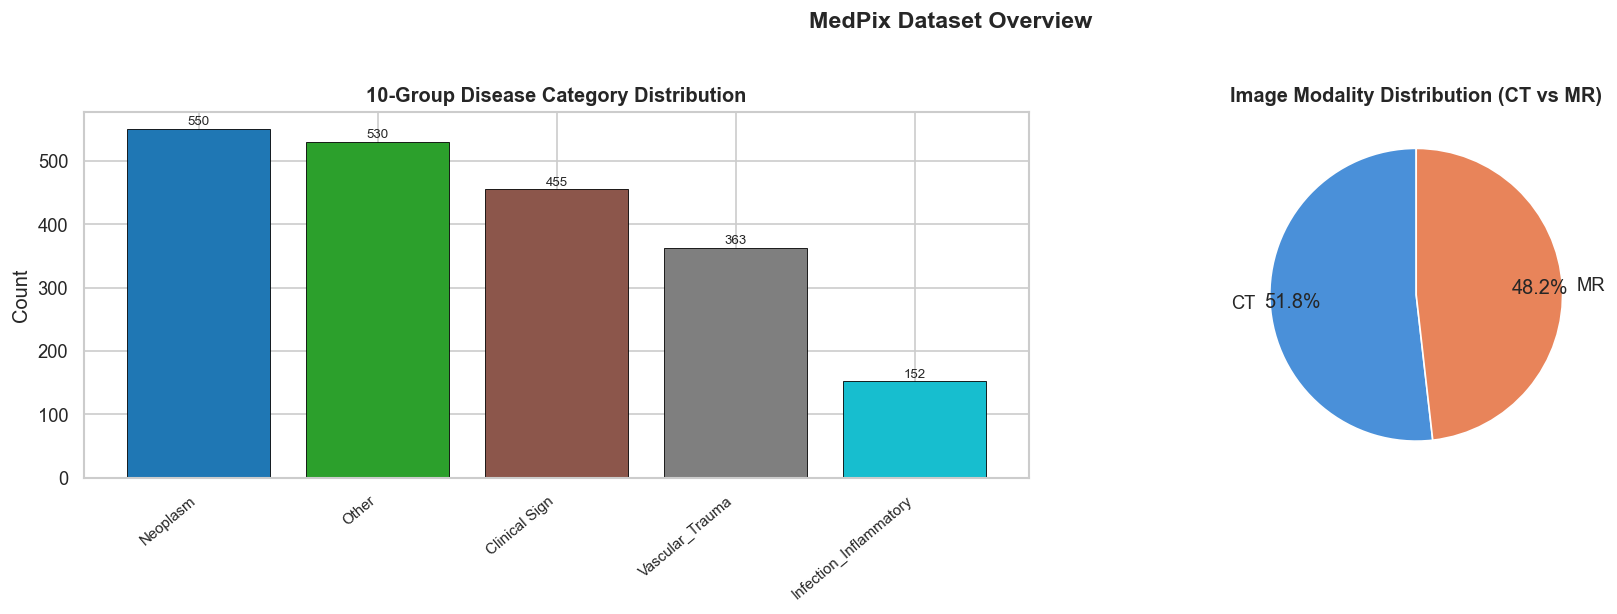

Chart saved to outputs/class_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Plot 1: 10-class grouped distribution ────────────────────────────────
label_counts = df['label_name'].value_counts().sort_values(ascending=False)
colors = plt.cm.tab10(np.linspace(0, 1, len(label_counts)))
axes[0].bar(range(len(label_counts)), label_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=40, ha='right', fontsize=9)
axes[0].set_title('10-Group Disease Category Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=8)

# ── Plot 2: Modality breakdown ────────────────────────────────────────────
mod_counts = df['modality'].value_counts()
axes[1].pie(mod_counts.values, labels=mod_counts.index, autopct='%1.1f%%',
            colors=['#4A90D9', '#E8845A'], startangle=90, pctdistance=0.85)
axes[1].set_title('Image Modality Distribution (CT vs MR)', fontweight='bold', fontsize=12)

plt.suptitle('MedPix Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Chart saved to outputs/class_distribution.png')

## 4️⃣ Medical Image Grid Visualization

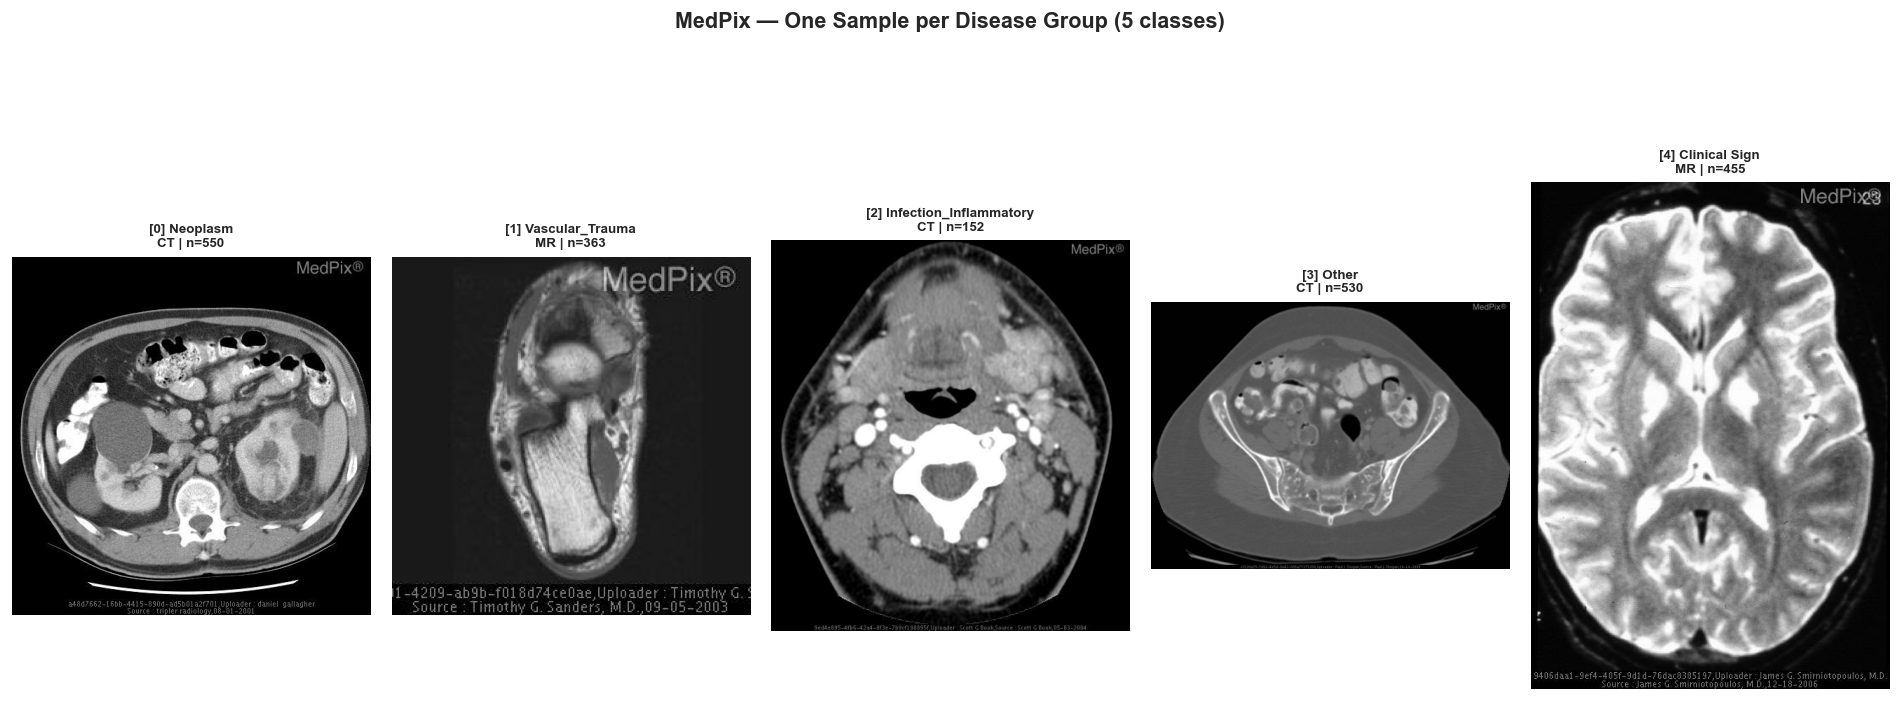

In [6]:
# Show one sample image per class in a 2×5 grid
fig, axes = plt.subplots(1, 5, figsize=(16, 7))
axes = axes.flatten()

for label_idx, ax in enumerate(axes):
    class_name = config.CLASS_NAMES[label_idx]
    subset = df[df['label'] == label_idx]
    
    if len(subset) == 0:
        ax.axis('off')
        ax.set_title(f'{class_name}\n(no samples)', fontsize=8)
        continue
    
    sample = subset.sample(1, random_state=42).iloc[0]
    try:
        img = Image.open(sample['image_path']).convert('RGB')
        ax.imshow(img, cmap='gray')
    except:
        ax.imshow(np.zeros((224, 224, 3), dtype=np.uint8))
    
    modality = sample['modality']
    ax.set_title(f'[{label_idx}] {class_name}\n{modality} | n={len(subset)}', fontsize=8, fontweight='bold')
    ax.axis('off')

plt.suptitle('MedPix — One Sample per Disease Group (5 classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/image_grid.png', bbox_inches='tight', dpi=150)
plt.show()

## 5️⃣ Text Statistics

=== TEXT STATISTICS ===
       text_length  word_count
count       2050.0      2050.0
mean         770.8       117.2
std          462.0        70.3
min           10.0         1.0
25%          447.2        68.0
50%          653.5       101.0
75%          995.0       151.0
max         3412.0       509.0


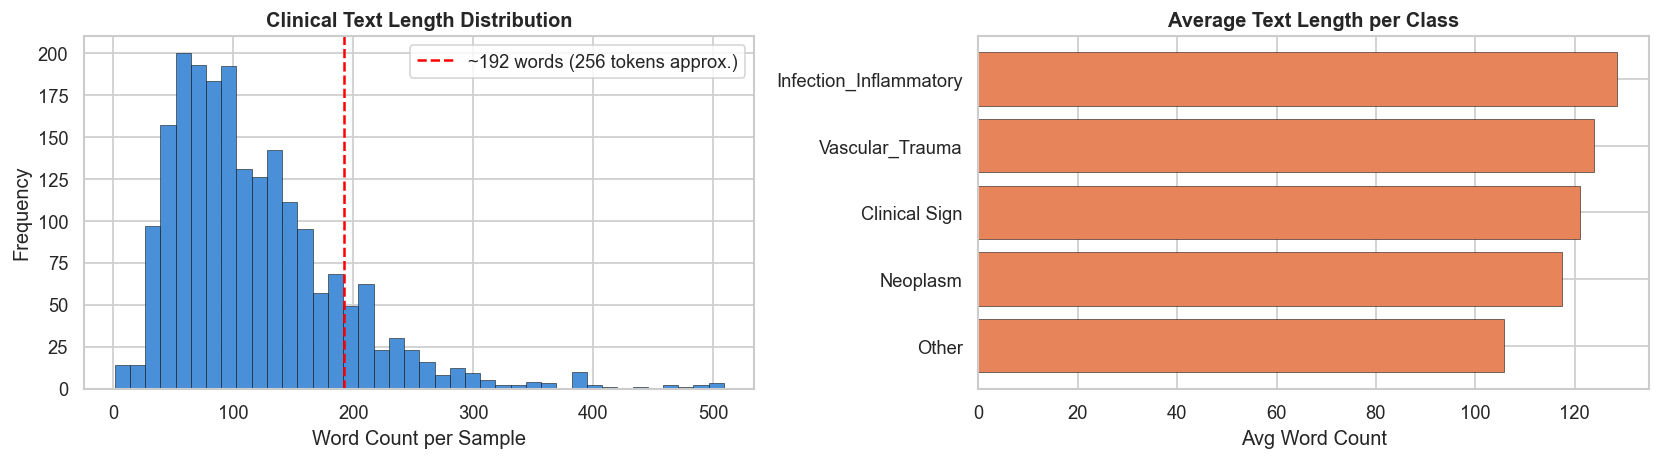

In [7]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

print('=== TEXT STATISTICS ===')
print(df[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['word_count'], bins=40, color='#4A90D9', edgecolor='black', linewidth=0.3)
axes[0].axvline(256 * 0.75, color='red', linestyle='--', label='~192 words (256 tokens approx.)')
axes[0].set_xlabel('Word Count per Sample')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Clinical Text Length Distribution', fontweight='bold')
axes[0].legend()

# Per-class average text length
class_txt_len = df.groupby('label_name')['word_count'].mean().sort_values()
axes[1].barh(class_txt_len.index, class_txt_len.values, color='#E8845A', edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Avg Word Count')
axes[1].set_title('Average Text Length per Class', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/text_stats.png', bbox_inches='tight', dpi=150)
plt.show()

## 6️⃣ Class Imbalance Analysis + Resampling Strategy

In [8]:
print('=== IMBALANCE ANALYSIS ===')
counts = df['label_name'].value_counts()
min_c, max_c = counts.min(), counts.max()
imbalance_ratio = max_c / min_c

print(f'Most common class:  {counts.idxmax()} ({max_c} samples)')
print(f'Least common class: {counts.idxmin()} ({min_c} samples)')
print(f'Imbalance ratio:    {imbalance_ratio:.1f}x')
print()

if imbalance_ratio > 3:
    print('⚠️  High imbalance detected (ratio > 3x)')
    print('Strategy: Use class_weight="balanced" in loss function (config.py default)')
    
    # Compute balanced class weights (sklearn convention)
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np
    cw = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(config.NUM_CLASSES),
        y=df['label'].values
    )
    print('\nComputed class weights for CrossEntropyLoss:')
    for i, w in enumerate(cw):
        print(f'  Class {i} ({config.CLASS_NAMES[i]}): weight = {w:.3f}')
else:
    print('✅ Imbalance ratio < 3x — standard CrossEntropyLoss is appropriate')

=== IMBALANCE ANALYSIS ===
Most common class:  Neoplasm (550 samples)
Least common class: Infection_Inflammatory (152 samples)
Imbalance ratio:    3.6x

⚠️  High imbalance detected (ratio > 3x)
Strategy: Use class_weight="balanced" in loss function (config.py default)

Computed class weights for CrossEntropyLoss:
  Class 0 (Neoplasm): weight = 0.745
  Class 1 (Vascular_Trauma): weight = 1.129
  Class 2 (Infection_Inflammatory): weight = 2.697
  Class 3 (Other): weight = 0.774
  Class 4 (Clinical Sign): weight = 0.901


## 7️⃣ Save Dataset Summary

In [9]:
import json

summary = {
    'total_samples':    int(len(df)),
    'num_classes':      config.NUM_CLASSES,
    'class_names':      config.CLASS_NAMES,
    'class_counts':     {config.CLASS_NAMES[int(k)]: int(v) for k, v in df['label'].value_counts().items()},
    'modality_counts':  df['modality'].value_counts().to_dict(),
    'location_counts':  df['location_category'].value_counts().to_dict(),
    'avg_word_count':   float(df['word_count'].mean()),
    'avg_text_length':  float(df['text_length'].mean()),
    'imbalance_ratio':  float(imbalance_ratio),
}

with open(config.DATASET_SUMMARY_PATH, 'w') as f:
    json.dump(summary, f, indent=2)

print('Dataset summary saved to:', config.DATASET_SUMMARY_PATH)
print(json.dumps(summary, indent=2))

# Save the master dataframe for use in notebook 02
df.to_csv('../data/medpix_master.csv', index=False)
print('\nMaster DataFrame saved to: data/medpix_master.csv')
print(f'Total columns: {list(df.columns)}')

Dataset summary saved to: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\data\dataset_summary.json
{
  "total_samples": 2050,
  "num_classes": 5,
  "class_names": [
    "Neoplasm",
    "Vascular_Trauma",
    "Infection_Inflammatory",
    "Other",
    "Clinical Sign"
  ],
  "class_counts": {
    "Neoplasm": 550,
    "Other": 530,
    "Clinical Sign": 455,
    "Vascular_Trauma": 363,
    "Infection_Inflammatory": 152
  },
  "modality_counts": {
    "CT": 1062,
    "MR": 988
  },
  "location_counts": {
    "Head": 884,
    "Spine and Muscles": 355,
    "Thorax": 334,
    "Abdomen": 319,
    "Reproductive and Urinary System": 158
  },
  "avg_word_count": 117.19268292682926,
  "avg_text_length": 770.829756097561,
  "imbalance_ratio": 3.6184210526315788
}

Master DataFrame saved to: data/medpix_master.csv
Total columns: ['image_id', 'image_path', 'U_id', 'modality', 'location', 'location_category', 'plane', 'age', 'sex', 'caption', 'history'